# Compare Features per Brain Slice

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import random
import pyvips
import numpy as np
import cv2
from tqdm import tqdm
import pandas as pd
from scripts.filters import *
from scripts.utils import *
from cell_analysis.extract_features import *
import pandas as pd
from shapely.geometry import box as shapely_box

res = pd.read_parquet("./results/new/microglia_features_slice.parquet")
print(len(res))

112930


## Calculate Additional Sholl Features

In [2]:
def compute_sholl_feats(row):
    radii = np.arange(10, 241, 10)

    sholl_cols = [f"sholl_{r}" for r in radii]
    counts = row[sholl_cols].values.astype(float)
    index = np.where(counts == 0)[0]
    SHOLL_DEPTH = index[0] if len(index) > 0 else 250
    SHOLL_MAX = counts.max()
    SHOLL_AUC = np.trapz(counts, radii)
    peak_idx = counts.argmax()
    post_peak_counts = counts[peak_idx:]
    post_peak_radii = radii[peak_idx:]

    valid = post_peak_counts > 0
    if valid.sum() >= 2:
        log_counts = np.log(post_peak_counts[valid])
        slope, _ = np.polyfit(post_peak_radii[valid], log_counts, 1)
        SHOLL_DECAY = slope
    else:
        SHOLL_DECAY = np.nan

    return pd.Series(
        {
            "sholl_depth": SHOLL_DEPTH,
            "sholl_max": SHOLL_MAX,
            "sholl_auc": SHOLL_AUC,
            "sholl_decay": SHOLL_DECAY,
        }
    )


df = res.copy()
metrics = df.apply(compute_sholl_feats, axis=1)
df = pd.concat([df, metrics], axis=1)
df.to_parquet("./results/new/microglia_feats_extended.parquet")

In [3]:
res = pd.read_parquet("./results/new/microglia_feats_extended.parquet")

feature_cols = [
    c
    for c in res.columns
    if c
    not in [
        "slide",
        "label",
        "x1",
        "y1",
        "x2",
        "y2",
        "cx",
        "cy",
        "brain_slice",
        "gmm_cluster",
        "gmm_confidence",
        "region",
    ]
]

res[feature_cols] = res[feature_cols].replace([np.inf, -np.inf], np.nan)

avg_features = res.groupby(["slide", "brain_slice"])[feature_cols].mean().reset_index()
slide_label_map = res[["slide", "label"]].drop_duplicates().set_index("slide")["label"]
avg_features["label"] = avg_features["slide"].map(slide_label_map)
avg_features

,slide,brain_slice,soma_area,soma_radius,cell_area,solidity,circularity,n_branches,n_junctions,mean_branch_len,...,sholl_210,sholl_220,sholl_230,sholl_240,sholl_250,sholl_depth,sholl_max,sholl_auc,sholl_decay,label
0,TPO_60,1,1792.810162,27.586036,15756.672548,0.311497,0.789667,120.853917,71.326041,4.139364,...,0.707833,0.501764,0.400141,0.291461,0.033874,37.634439,14.235004,1219.428370,-0.023418,1
1,TPO_60,2,1538.920390,25.608368,13708.848485,0.323619,0.758767,102.256292,59.546482,4.194592,...,0.580894,0.468413,0.338983,0.270159,0.038007,33.894710,12.775552,1034.101181,-0.023809,1
2,TPO_60,3,1692.811526,26.807471,14067.354275,0.334865,0.755484,98.822863,57.157770,4.203111,...,0.495985,0.386396,0.292867,0.204535,0.017005,32.581011,12.462919,982.130373,-0.024287,1
3,TPO_60,4,1712.993980,26.792770,15188.494883,0.360087,0.759547,111.782661,65.452739,3.966886,...,0.603251,0.443107,0.346779,0.262492,0.036123,31.577363,13.043347,1034.954846,-0.025251,1
4,TPO_60,5,1705.342279,26.616658,15814.926083,0.361805,0.764038,115.706685,68.141714,3.945636,...,0.556968,0.433145,0.324388,0.243409,0.037194,30.169492,13.376648,1072.561205,-0.024204,1
5,TPO_61_EV,1,1846.340437,27.595231,14298.480249,0.350351,0.770570,106.122141,62.195946,4.051263,...,0.458940,0.321726,0.259356,0.214657,0.018711,27.919439,13.011435,1009.051455,-0.024005,0
6,TPO_61_EV,2,1669.722906,26.746624,13707.935292,0.344793,0.761368,99.712584,57.912664,4.073260,...,0.468440,0.340611,0.245335,0.173879,0.032950,27.054784,12.560540,959.503771,-0.025006,0
7,TPO_61_EV,3,1715.797572,26.909784,13823.124672,0.364488,0.759512,97.058727,56.292651,4.050567,...,0.444554,0.332349,0.247047,0.187008,0.033793,26.542979,12.217192,909.032152,-0.025724,0
8,TPO_61_EV,4,1865.009539,27.801008,13867.389905,0.367887,0.753384,94.774245,54.766296,4.079599,...,0.416534,0.326709,0.268283,0.192766,0.030604,27.733704,11.825119,880.266296,-0.025198,0
9,TPO_61_EV,5,1954.322338,28.437398,15667.827975,0.369479,0.763012,113.253445,66.562004,3.960487,...,0.668894,0.490188,0.394572,0.292693,0.060125,32.782463,13.045094,1027.778706,-0.024569,0


In [4]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


def remove_outliers_iqr(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return series[(series >= lower) & (series <= upper)]


def run_mwu_per_slide_feature(avg_features_df, feature_cols, outlier_k=1.5):
    results = []
    g1 = 0
    g2 = 1
    g1_df = avg_features_df[avg_features_df["label"] == 0]
    g2_df = avg_features_df[avg_features_df["label"] == 1]

    for feat in feature_cols:
        g1_vals = g1_df[feat].dropna()
        g2_vals = g2_df[feat].dropna()

        g1_clean = remove_outliers_iqr(g1_vals, k=outlier_k)
        g2_clean = remove_outliers_iqr(g2_vals, k=outlier_k)

        row = {
            "feature": feat,
            f"n_{g1}": len(g1_clean),
            f"n_{g2}": len(g2_clean),
            f"mean_{g1}": g1_clean.mean(),
            f"mean_{g2}": g2_clean.mean(),
            f"n_removed_{g1}": len(g1_vals) - len(g1_clean),
            f"n_removed_{g2}": len(g2_vals) - len(g2_clean),
            "stat": np.nan,
            "p_value": np.nan,
        }

        if len(g1_clean) < 2 or len(g2_clean) < 2:
            results.append(row)
            continue

        stat, p = mannwhitneyu(g1_clean, g2_clean, alternative="two-sided")
        row.update({"stat": stat, "p_value": p})
        results.append(row)

    results_df = pd.DataFrame(results).set_index(["feature"])
    valid = results_df["p_value"].notna()
    _, p_adj, _, _ = multipletests(results_df.loc[valid, "p_value"], method="holm")
    results_df.loc[valid, "p_adj_holm"] = p_adj

    return results_df.sort_values("p_value")


mwu_results = run_mwu_per_slide_feature(avg_features, feature_cols)
mwu_results.to_parquet("./results/new/microglia_avg_slide_analysis.parquet")
mwu_results

,n_0,n_1,mean_0,mean_1,n_removed_0,n_removed_1,stat,p_value,p_adj_holm
feature,,,,,,,,,
sholl_190,28,24,0.823609,1.149078,6,0,173.0,0.002856,0.117113
sholl_200,28,24,0.634400,0.902343,6,0,180.0,0.004313,0.172531
sholl_220,28,24,0.362101,0.542654,6,0,183.0,0.005123,0.199779
sholl_210,28,24,0.483451,0.703225,6,0,184.0,0.005421,0.206011
sholl_230,29,24,0.293755,0.418985,5,0,207.0,0.012055,0.446035
sholl_180,30,24,1.148468,1.441235,4,0,220.0,0.015166,0.545987
sholl_170,30,24,1.458442,1.799618,4,0,223.0,0.017494,0.612286
sholl_160,31,24,1.889295,2.248364,3,0,238.5,0.023996,0.815854
sholl_40,31,24,8.660628,9.196216,3,0,239.0,0.024533,0.815854


## Visualize Cells

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def make_boxplot(df, feature, y_val, max_fliers=500):
    groups = sorted(df[y_val].unique())
    stats = []
    for g in groups:
        vals = df.loc[df[y_val] == g, feature].dropna()
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        fliers = vals[(vals < lower) | (vals > upper)]
        print(f"Group {g} has {len(fliers)} fliers.")
        print(f"Group {g} has flier mean {np.mean(fliers)}.")
        if len(fliers) > max_fliers:
            fliers = fliers.sample(max_fliers, random_state=42)

        stats.append(
            {
                "group": g,
                "med": med,
                "q1": q1,
                "q3": q3,
                "whislo": vals[vals >= lower].min(),
                "whishi": vals[vals <= upper].max(),
                "fliers": fliers.values,
            }
        )

    fig, ax = plt.subplots()
    ax.bxp(stats, showfliers=True)
    ax.set_xticklabels([s["group"] for s in stats])
    ax.set_ylabel(feature)
    plt.show()

Group 0 has 2278 fliers.
Group 0 has flier mean 1378.6817257113826.
Group 1 has 1402 fliers.
Group 1 has flier mean 1426.92016643763.


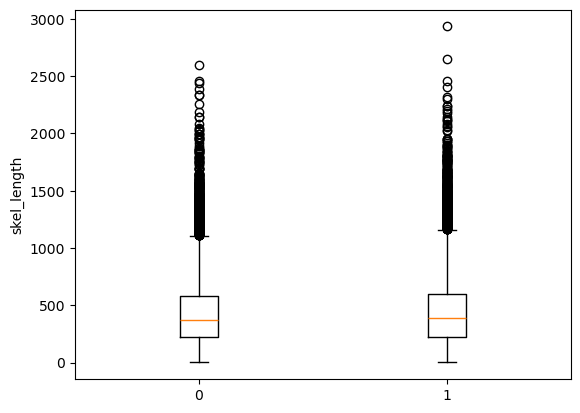

Group 0 has 970 fliers.
Group 0 has flier mean 250.0.
Group 1 has 657 fliers.
Group 1 has flier mean 250.0.


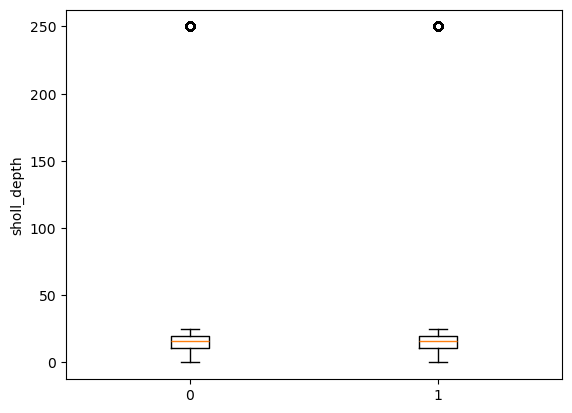

Group 0 has 3914 fliers.
Group 0 has flier mean -0.07755041511244541.
Group 1 has 2869 fliers.
Group 1 has flier mean -0.07699804517687853.


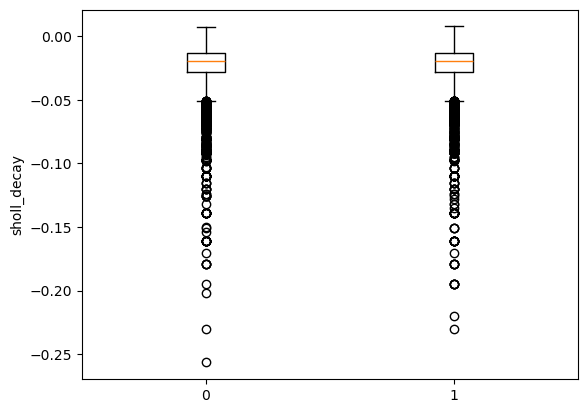

Group 0 has 2664 fliers.
Group 0 has flier mean 6079.92454954955.
Group 1 has 2025 fliers.
Group 1 has flier mean 6026.421234567902.


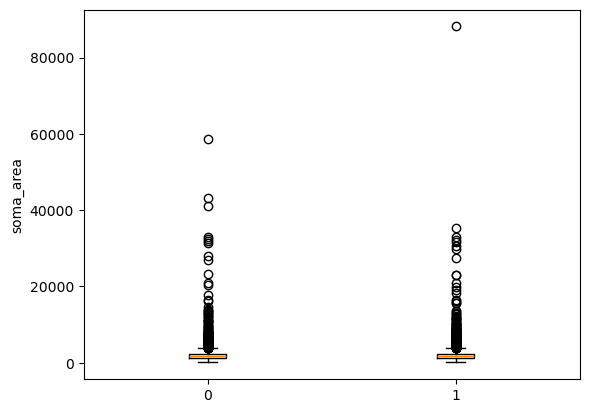

In [11]:
res = pd.read_parquet("./results/new2/microglia_feats_extended.parquet")
# region = "STR"
# res = res[res["region"] == region]
y = "label"


x = "skel_length"
make_boxplot(res, x, y)

x = "sholl_depth"
make_boxplot(res, x, y)


x = "sholl_decay"
make_boxplot(res, x, y)

x = "soma_area"
make_boxplot(res, x, y)

Group 0 has 376 fliers.
Group 0 has flier mean 1544.351212375627.
Group 1 has 186 fliers.
Group 1 has flier mean 1654.505092628567.


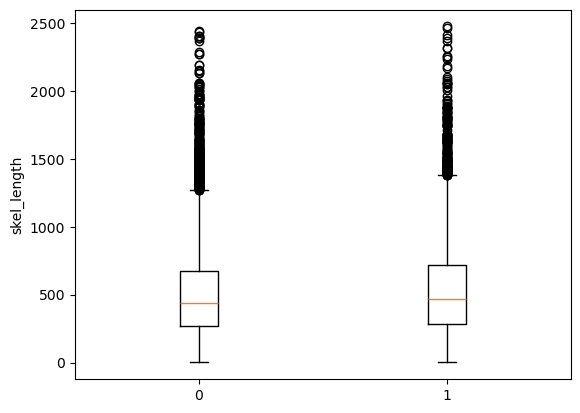

Group 0 has 285 fliers.
Group 0 has flier mean 221.9298245614035.
Group 1 has 184 fliers.
Group 1 has flier mean 250.0.


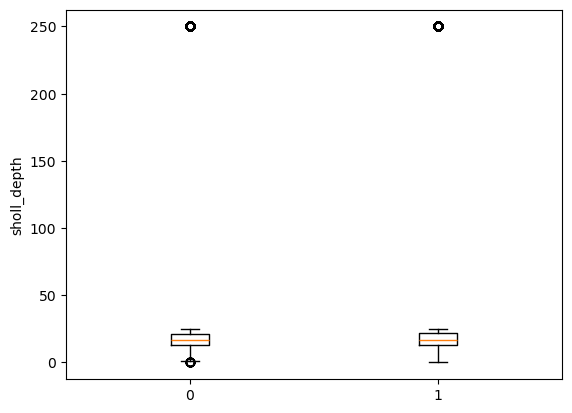

Group 0 has 552 fliers.
Group 0 has flier mean -0.0736705517712859.
Group 1 has 394 fliers.
Group 1 has flier mean -0.07527251503868244.


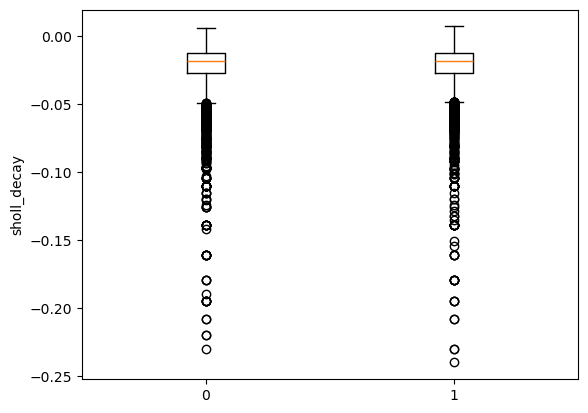

Group 0 has 390 fliers.
Group 0 has flier mean 5127.451282051282.
Group 1 has 330 fliers.
Group 1 has flier mean 5309.633333333333.


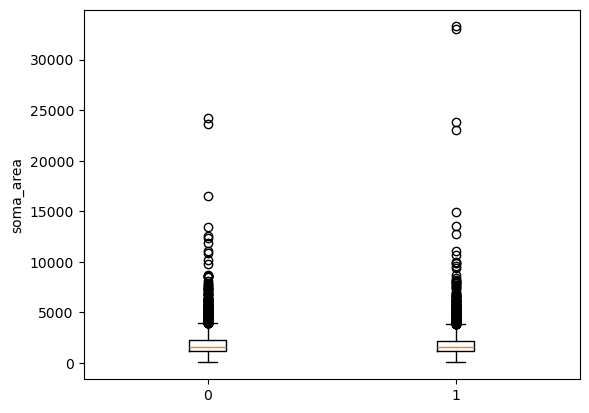

In [12]:
res = pd.read_parquet("./results/new2/microglia_region_split.parquet")
region = "STR"
res = res[res["region"] == region]
y = "label"


x = "skel_length"
make_boxplot(res, x, y)

x = "sholl_depth"
make_boxplot(res, x, y)

x = "sholl_decay"
make_boxplot(res, x, y)

x = "soma_area"
make_boxplot(res, x, y)